Measuring LJ (none)...
Measuring LJ (shift)...
Measuring LJ (xplor)...
Measuring ForceShiftedLJ...
Saved: /home/pnichols/MDsims/Plots/HOOMD/PairPotentials/lj_cutoff_potential_force_comparison.png


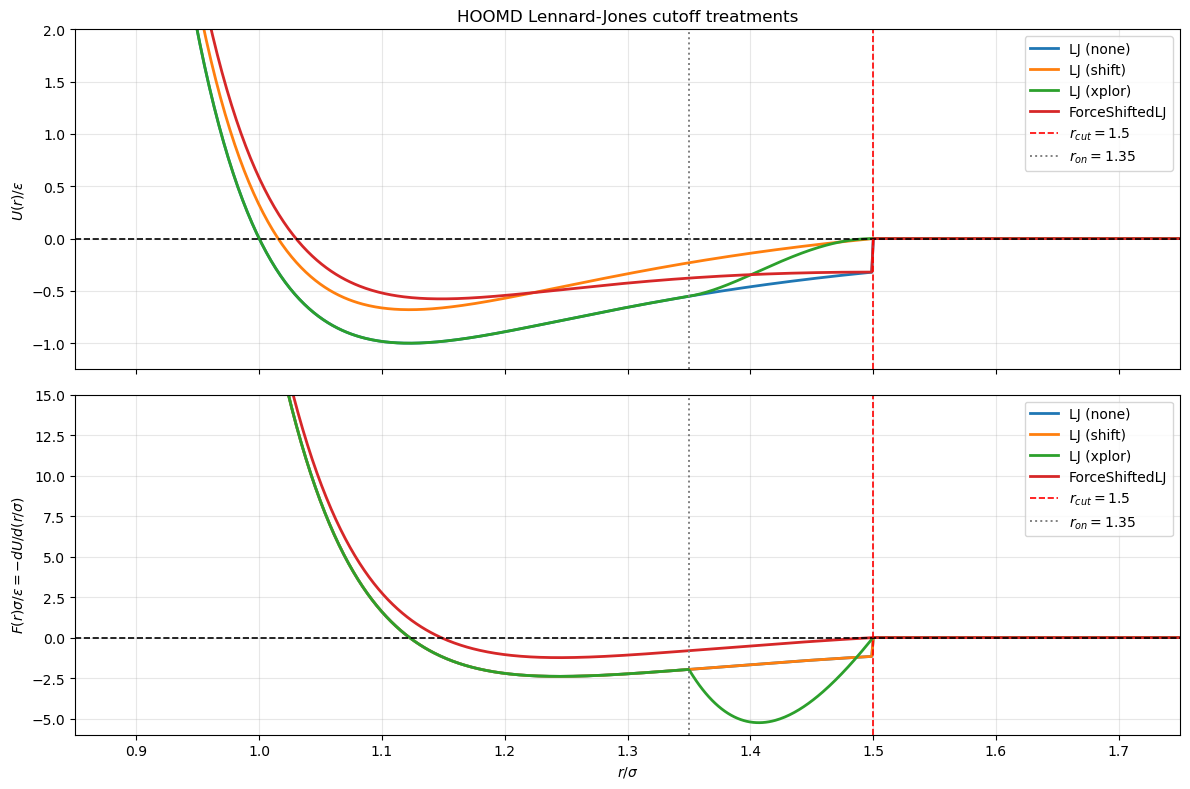

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import md_Helpers

from examples.plot_lj_modes import (
    make_pair_forces,
    measure_pair_interaction,
)


# ============================================================
# User settings
# ============================================================

epsilon_LJ = 1.0
sigma_LJ = 1.0

r_cut = 1.5 * sigma_LJ
r_on = 1.35 * sigma_LJ
neighbor_buffer = 0.4

r_min = 0.85 * sigma_LJ
r_max = 1.75 * sigma_LJ
number_of_samples = 700

save_plot = True


# ============================================================
# Validate settings
# ============================================================

if not 0 < r_on < r_cut:
    raise ValueError("r_on must satisfy 0 < r_on < r_cut.")

if r_min <= 0:
    raise ValueError("r_min must be positive.")

if r_max <= r_cut:
    raise ValueError(
        "r_max should be greater than r_cut so the zero-force "
        "region beyond the cutoff is visible."
    )

if number_of_samples < 2:
    raise ValueError("number_of_samples must be at least 2.")


# ============================================================
# Construct the separation grid
# ============================================================

r_values = np.linspace(
    r_min,
    r_max,
    number_of_samples,
)


# ============================================================
# Construct the four HOOMD pair-force treatments
# ============================================================

pair_forces = make_pair_forces(
    r_cut=r_cut,
    r_on=r_on,
    buffer=neighbor_buffer,
)

# Override epsilon and sigma if values other than 1 are requested.
for pair_force in pair_forces.values():
    pair_force.params[("A", "A")] = {
        "epsilon": epsilon_LJ,
        "sigma": sigma_LJ,
    }


# ============================================================
# Measure U(r) and F(r) directly using two-particle systems
# ============================================================

results = {}

for label, pair_force in pair_forces.items():
    print(f"Measuring {label}...")

    potential, radial_force = measure_pair_interaction(
        pair_force=pair_force,
        separations=r_values,
        box_length=30.0 * sigma_LJ,
    )

    results[label] = {
        "potential": potential,
        "force": radial_force,
    }


# ============================================================
# Plot potential and force
# ============================================================

fig, (ax_U, ax_F) = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
)

for label, values in results.items():
    ax_U.plot(
        r_values / sigma_LJ,
        values["potential"] / epsilon_LJ,
        linewidth=2,
        label=label,
    )

    ax_F.plot(
        r_values / sigma_LJ,
        values["force"] * sigma_LJ / epsilon_LJ,
        linewidth=2,
        label=label,
    )


# ============================================================
# Reference lines and formatting
# ============================================================

for ax in (ax_U, ax_F):
    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.axvline(
        r_cut / sigma_LJ,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=rf"$r_{{cut}}={r_cut / sigma_LJ:g}$",
    )

    ax.axvline(
        r_on / sigma_LJ,
        color="gray",
        linestyle=":",
        linewidth=1.4,
        label=rf"$r_{{on}}={r_on / sigma_LJ:g}$",
    )

    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")


ax_U.set_ylabel(r"$U(r)/\epsilon$")
ax_U.set_ylim(-1.25, 2.0)
ax_U.set_title(
    "HOOMD Lennard-Jones cutoff treatments"
)

ax_F.set_xlabel(r"$r/\sigma$")
ax_F.set_ylabel(r"$F(r)\sigma/\epsilon=-dU/d(r/\sigma)$")
ax_F.set_ylim(-6, 15)

ax_F.set_xlim(
    r_min / sigma_LJ,
    r_max / sigma_LJ,
)

fig.tight_layout()


# ============================================================
# Save and display
# ============================================================

if save_plot:
    project_root = (
        Path(md_Helpers.__file__)
        .resolve()
        .parent
        .parent
    )

    output_path = (
        project_root
        / "Plots"
        / "HOOMD"
        / "PairPotentials"
        / "lj_cutoff_potential_force_comparison.png"
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"Saved: {output_path}")

plt.show()